In [1]:
import pandas as pd
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
import numpy as np
import astropy.units as u
from astropy.coordinates import frame_transform_graph
from matplotlib.path import Path
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

# params = {
#     "text.usetex": True,
#     "font.family": "serif",
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True,
#     "xtick.top": True,
#     "ytick.left": True,
#     "ytick.right": True,
#     "xtick.direction": "out",
#     "ytick.direction": "out",
#     "xtick.minor.size": 2.5,
#     "xtick.major.size": 5,
#     "ytick.minor.size": 2.5,
#     "ytick.major.size": 5,
#     "axes.axisbelow": True,
# }
# plt.rcParams.update(params)

In [2]:
raw_data = pd.read_csv("gaia_raw_query.csv")
raw_data.columns

Index(['source_id', 'ra', 'dec', 'parallax', 'parallax_error', 'pmra',
       'pmra_error', 'pmdec', 'pmdec_error', 'g', 'bp', 'rp', 'bp_rp',
       'radial_velocity', 'radial_velocity_error', 'ruwe'],
      dtype='object')

In [3]:
class GD1Stream(coord.BaseCoordinateFrame):
    """Custom GD-1 stream coordinate frame."""

    default_representation = coord.SphericalRepresentation
    frame_specific_diff_type = {"s": coord.SphericalCosLatDifferential}

In [ ]:
"""
    Transform Gaia ICRS coordinates to the GD-1 stream frame.

    From the paper (Section 2, Figure 3):
    "The center panel shows the Gaia proper motions transformed
    into a coordinate system aligned with the stream,
    (μ_φ1,*, μ_φ2), where φ1 is the stream longitude and φ2 is
    the stream latitude."

    This is the key step that makes the stream visible — in ICRS
    the stream is spread across a huge area, but in the stream
    frame it's a thin line near phi2 ≈ 0.
    """
# Create SkyCoord with proper motions
coords = SkyCoord(
    ra=raw_data["ra"].values * u.deg,
    dec=raw_data["dec"].values * u.deg,
    pm_ra_cosdec=raw_data["pmra"].values * u.mas / u.yr,
    pm_dec=raw_data["pmdec"].values * u.mas / u.yr,
)

In [ ]:
"""
    Manual coordinate rotation to GD-1 frame.
    Implements the rotation from Koposov et al. (2010).
"""

# Rotation matrix from Koposov et al. (2010)
R = np.array(
    [
        [-0.4776303088, -0.1738432154, 0.8611897727],
        [0.510844589, -0.8524449229, 0.111245042],
        [0.7147776536, 0.4930681392, 0.4959603976],
    ]
)

ra_rad = np.deg2rad(coords.ra.deg)
dec_rad = np.deg2rad(coords.dec.deg)

# Convert to Cartesian on unit sphere
x = np.cos(dec_rad) * np.cos(ra_rad)
y = np.cos(dec_rad) * np.sin(ra_rad)
z = np.sin(dec_rad)
xyz = np.vstack([x, y, z])

# Rotate
xyz_rot = R @ xyz

# Back to spherical
phi1 = np.rad2deg(np.arctan2(xyz_rot[1], xyz_rot[0]))
phi2 = np.rad2deg(np.arcsin(xyz_rot[2]))

# Transform proper motions (rotation of the tangent plane)
# This requires computing the Jacobian of the transformation
cos_phi1 = np.cos(np.deg2rad(phi1))
sin_phi1 = np.sin(np.deg2rad(phi1))
cos_phi2 = np.cos(np.deg2rad(phi2))
sin_phi2 = np.sin(np.deg2rad(phi2))
cos_ra = np.cos(ra_rad)
sin_ra = np.sin(ra_rad)
cos_dec = np.cos(dec_rad)
sin_dec = np.sin(dec_rad)

# Jacobian elements for PM transformation
# d(phi1)/d(ra), d(phi1)/d(dec), d(phi2)/d(ra), d(phi2)/d(dec)
# Computed from the chain rule through the rotation
pmra = coords.pm_ra_cosdec.value
pmdec = coords.pm_dec.value

# Numerical Jacobian (robust approach)
delta = 1e-6  # rad
pm_phi1 = np.zeros(len(coords))
pm_phi2 = np.zeros(len(coords))

for i in range(len(coords)):
    # Perturb RA
    ra_p = ra_rad[i] + delta
    x_p = np.cos(dec_rad[i]) * np.cos(ra_p)
    y_p = np.cos(dec_rad[i]) * np.sin(ra_p)
    z_p = np.sin(dec_rad[i])
    rot_p = R @ np.array([x_p, y_p, z_p])
    dphi1_dra = (np.arctan2(rot_p[1], rot_p[0]) - np.deg2rad(phi1[i])) / delta
    dphi2_dra = (np.arcsin(rot_p[2]) - np.deg2rad(phi2[i])) / delta

    # Perturb Dec
    dec_p = dec_rad[i] + delta
    x_p = np.cos(dec_p) * np.cos(ra_rad[i])
    y_p = np.cos(dec_p) * np.sin(ra_rad[i])
    z_p = np.sin(dec_p)
    rot_p = R @ np.array([x_p, y_p, z_p])
    dphi1_ddec = (np.arctan2(rot_p[1], rot_p[0]) - np.deg2rad(phi1[i])) / delta
    dphi2_ddec = (np.arcsin(rot_p[2]) - np.deg2rad(phi2[i])) / delta

    # Transform: pm_phi1*cos(phi2) and pm_phi2
    pm_phi1[i] = (dphi1_dra * pmra[i] / cos_dec[i] + dphi1_ddec * pmdec[i]) * cos_phi2[
        i
    ]
    pm_phi2[i] = dphi2_dra * pmra[i] / cos_dec[i] + dphi2_ddec * pmdec[i]
    if i % 1000000 == 0:
        print(f"Processed {i} / {len(coords)} stars")

In [32]:
# save to CSV for later use, append to exisiting file
df = pd.DataFrame(
    {
        "ra": coords.ra.deg,
        "dec": coords.dec.deg,
        "phi1": phi1,
        "phi2": phi2,
        "pm_ra": coords.pm_ra_cosdec.value,
        "pm_dec": coords.pm_dec.value,
        "pm_phi1": pm_phi1,
        "pm_phi2": pm_phi2,
        "bp_rp": raw_data["bp_rp"].values,
        "g_mag": raw_data["g"].values,
    }
)
df.to_csv("gaia_transformed.csv", index=False)

In [5]:
"""
    Apply a matched filter on the color-magnitude diagram.

    From the paper (Section 2.1, Figure 3):
    "The most effective method for using photometric data to
    identify streams is to apply a 'matched filter' to the
    color-magnitude distribution of stars to preferentially
    select or up-weight stars that are likely to be distant
    and low metallicity."

    For GD-1:
    - Distance ≈ 7.5 kpc (distance modulus ≈ 14.4)
    - Old, metal-poor population: [M/H] ≈ -2.2, Age ≈ 12 Gyr

    We define a selection polygon in the (BP-RP, G) CMD that
    traces an isochrone for this population shifted to the
    stream's distance.
"""

bp_rp = raw_data["bp_rp"]
g_mag = raw_data["g"]

# Define the matched filter polygon in (BP-RP, G) space
# This traces a PARSEC isochrone for:
#   [M/H] = -2.2, Age = 12 Gyr, distance = 7.5 kpc
# with a color width of ±0.1 mag to account for photometric errors
#
# The paper uses (g-i) from Pan-STARRS; here we use Gaia's native
# BP-RP color which serves the same purpose.

# Approximate isochrone track for GD-1 in Gaia photometry
# (BP-RP, G_apparent) at d = 7.5 kpc (DM ≈ 14.38)
# These define the blue and red edges of the selection polygon
isochrone_color = np.array([-0.05, 0.10, 0.30, 0.50, 0.70, 0.90, 1.10, 1.30, 1.50])
isochrone_mag = np.array([15.0, 16.0, 17.5, 18.5, 19.2, 19.8, 20.3, 20.6, 21.0])

# Selection polygon: buffer around isochrone
color_buffer = 0.15

# Blue edge (going faint to bright)
blue_edge_color = isochrone_color - color_buffer
blue_edge_mag = isochrone_mag

# Red edge (going bright to faint)
red_edge_color = isochrone_color + color_buffer
red_edge_mag = isochrone_mag

# Close the polygon
poly_color = np.concatenate(
    [blue_edge_color, red_edge_color[::-1], [blue_edge_color[0]]]
)
poly_mag = np.concatenate([blue_edge_mag, red_edge_mag[::-1], [blue_edge_mag[0]]])

# Also include the main sequence turn-off and subgiant branch
# region more broadly, plus the horizontal branch

# Extended CMD selection polygon for GD-1
# (BP-RP, G) vertices — captures MSTO through lower RGB
cmd_polygon = np.array(
    [
        # MSTO and subgiant branch (blue/bright end)
        [-0.15, 14.5],
        [-0.15, 16.5],
        # Main sequence going redward and fainter
        [0.0, 17.0],
        [0.2, 18.0],
        [0.4, 18.8],
        [0.6, 19.5],
        [0.8, 20.0],
        [1.0, 20.5],
        [1.2, 20.8],
        [1.4, 21.0],
        # Red edge going back up
        [1.6, 21.0],
        [1.4, 20.5],
        [1.2, 20.0],
        [1.0, 19.5],
        [0.8, 18.8],
        [0.6, 18.0],
        [0.4, 17.0],
        [0.2, 16.0],
        [0.1, 14.5],
        # Close
        [-0.15, 14.5],
    ]
)

path = Path(cmd_polygon)
points = np.column_stack([bp_rp, g_mag])

# Apply the filter
cmd_mask = path.contains_points(points)

# Additional cut: restrict to near the stream track
stream_region = np.abs(phi2) < 5.0  # within 5° of stream

cmd_mask = cmd_mask & stream_region

print(f"CMD matched filter: {cmd_mask.sum()} / {len(raw_data)} stars pass")
print(f"+ Stream region cut: {cmd_mask.sum()} stars remain")

CMD matched filter: 326651 / 25474794 stars pass
+ Stream region cut: 326651 stars remain


In [26]:
"""
    Select stars with proper motions consistent with GD-1.

    From the paper (Section 2.2, Figure 3):
    "The bottom row of panels shows the same data, but now with
    a matched filter applied to the photometry and a selection
    on the proper motions (shown as a red box in the bottom
    center panel)."

    GD-1's proper motion in the stream frame is approximately:
    - μ_φ1,* ≈ -12 to -2 mas/yr  (retrograde, fast-moving)
    - μ_φ2   ≈ -3 to +1 mas/yr   (small perpendicular motion)

    The tight clustering in PM space is what makes Gaia so
    powerful for stream studies — the stream stands out clearly
    even when it's buried in the foreground photometrically.
"""

# PM selection box in the stream-aligned frame
# These values are from Price-Whelan & Bonaca (2018)
pm_phi1_range = (-15.0, -7.5)  # mas/yr
pm_phi2_range = (-6.0, 0.0)  # mas/yr

pm_mask = (
    (pm_phi1 > pm_phi1_range[0])
    & (pm_phi1 < pm_phi1_range[1])
    & (pm_phi2 > pm_phi2_range[0])
    & (pm_phi2 < pm_phi2_range[1])
)

# Combine with CMD filter
full_mask = cmd_mask & pm_mask

print(f"PM filter: {pm_mask.sum()} / {len(pm_phi1)} stars pass")
print(f"CMD + PM combined: {full_mask.sum()} stars — these are GD-1 candidates")

PM filter: 1451164 / 25474794 stars pass
CMD + PM combined: 22873 stars — these are GD-1 candidates


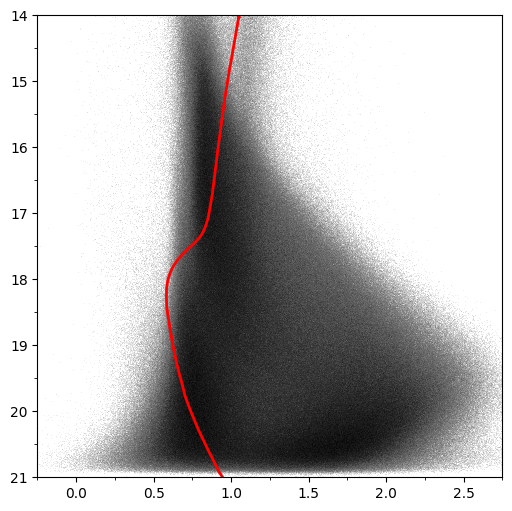

In [ ]:
bp_rp = raw_data["bp_rp"]
g_mag = raw_data["g"]

isochrone = pd.read_csv("isochrone.dat", sep=r"\s+", comment="#")
ms = isochrone[isochrone["label"].isin([1, 2, 3])]
g_iso = ms["G_fSBmag"]
bp_rp_iso = ms["G_BPft_fSBmag"] - ms["G_RP_fSBmag"]
dist_mod = np.log10(8300) * 5 - 5
g_iso = g_iso + dist_mod

fig, ax = plt.subplots(figsize=(6, 6))
ax.hist2d(
    bp_rp,
    g_mag,
    bins=1000,
    cmap="Grays",
    norm=mcolors.LogNorm(),
    range=[(-0.25, 2.75), (14, 21)],
)
ax.plot(bp_rp_iso, g_iso, color="red", lw=2, label="Isochrone (12 Gyr, [M/H]=-2.2)")
ax.set_ylim(21, 14)
ax.set_xlim(-0.25, 2.75)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

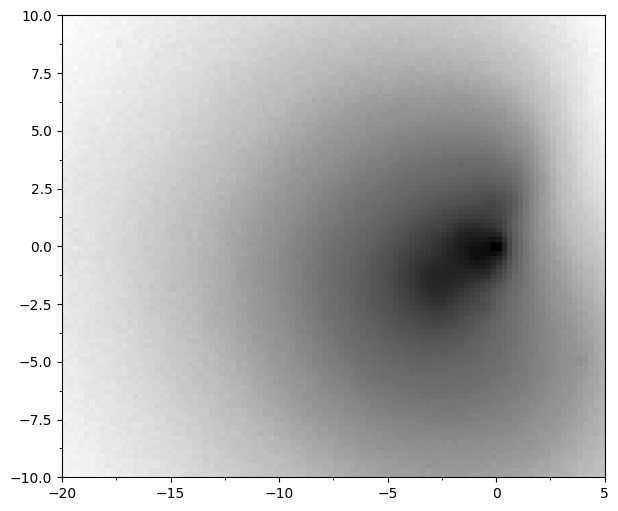

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist2d(
    pm_phi1,
    pm_phi2,
    bins=100,
    cmap="Greys",
    norm=mcolors.LogNorm(),
    range=[(-20, 5), (-10, 10)],
)
ax.set_ylim(-10, 10)
ax.set_xlim(-20, 5)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

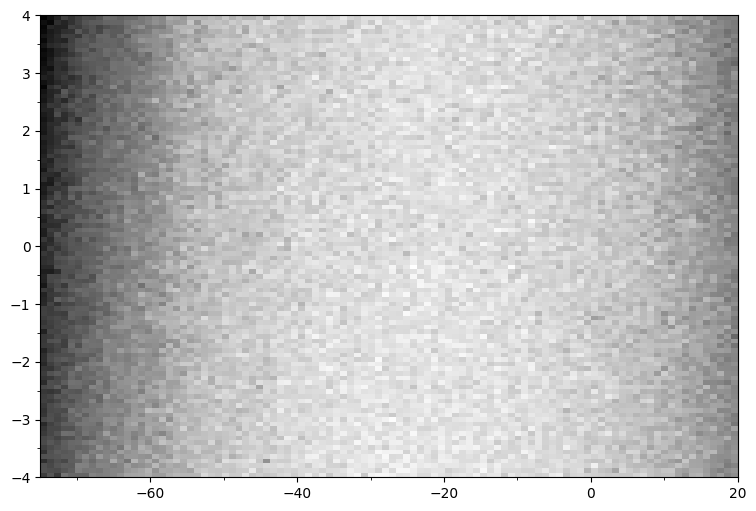

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist2d(
    phi1,
    phi2,
    bins=100,
    cmap="Grays",
    norm=mcolors.LogNorm(),
    range=[(-75, 20), (-4, 4)],
)
ax.set_ylim(-4, 4)
ax.set_xlim(-75, 20)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

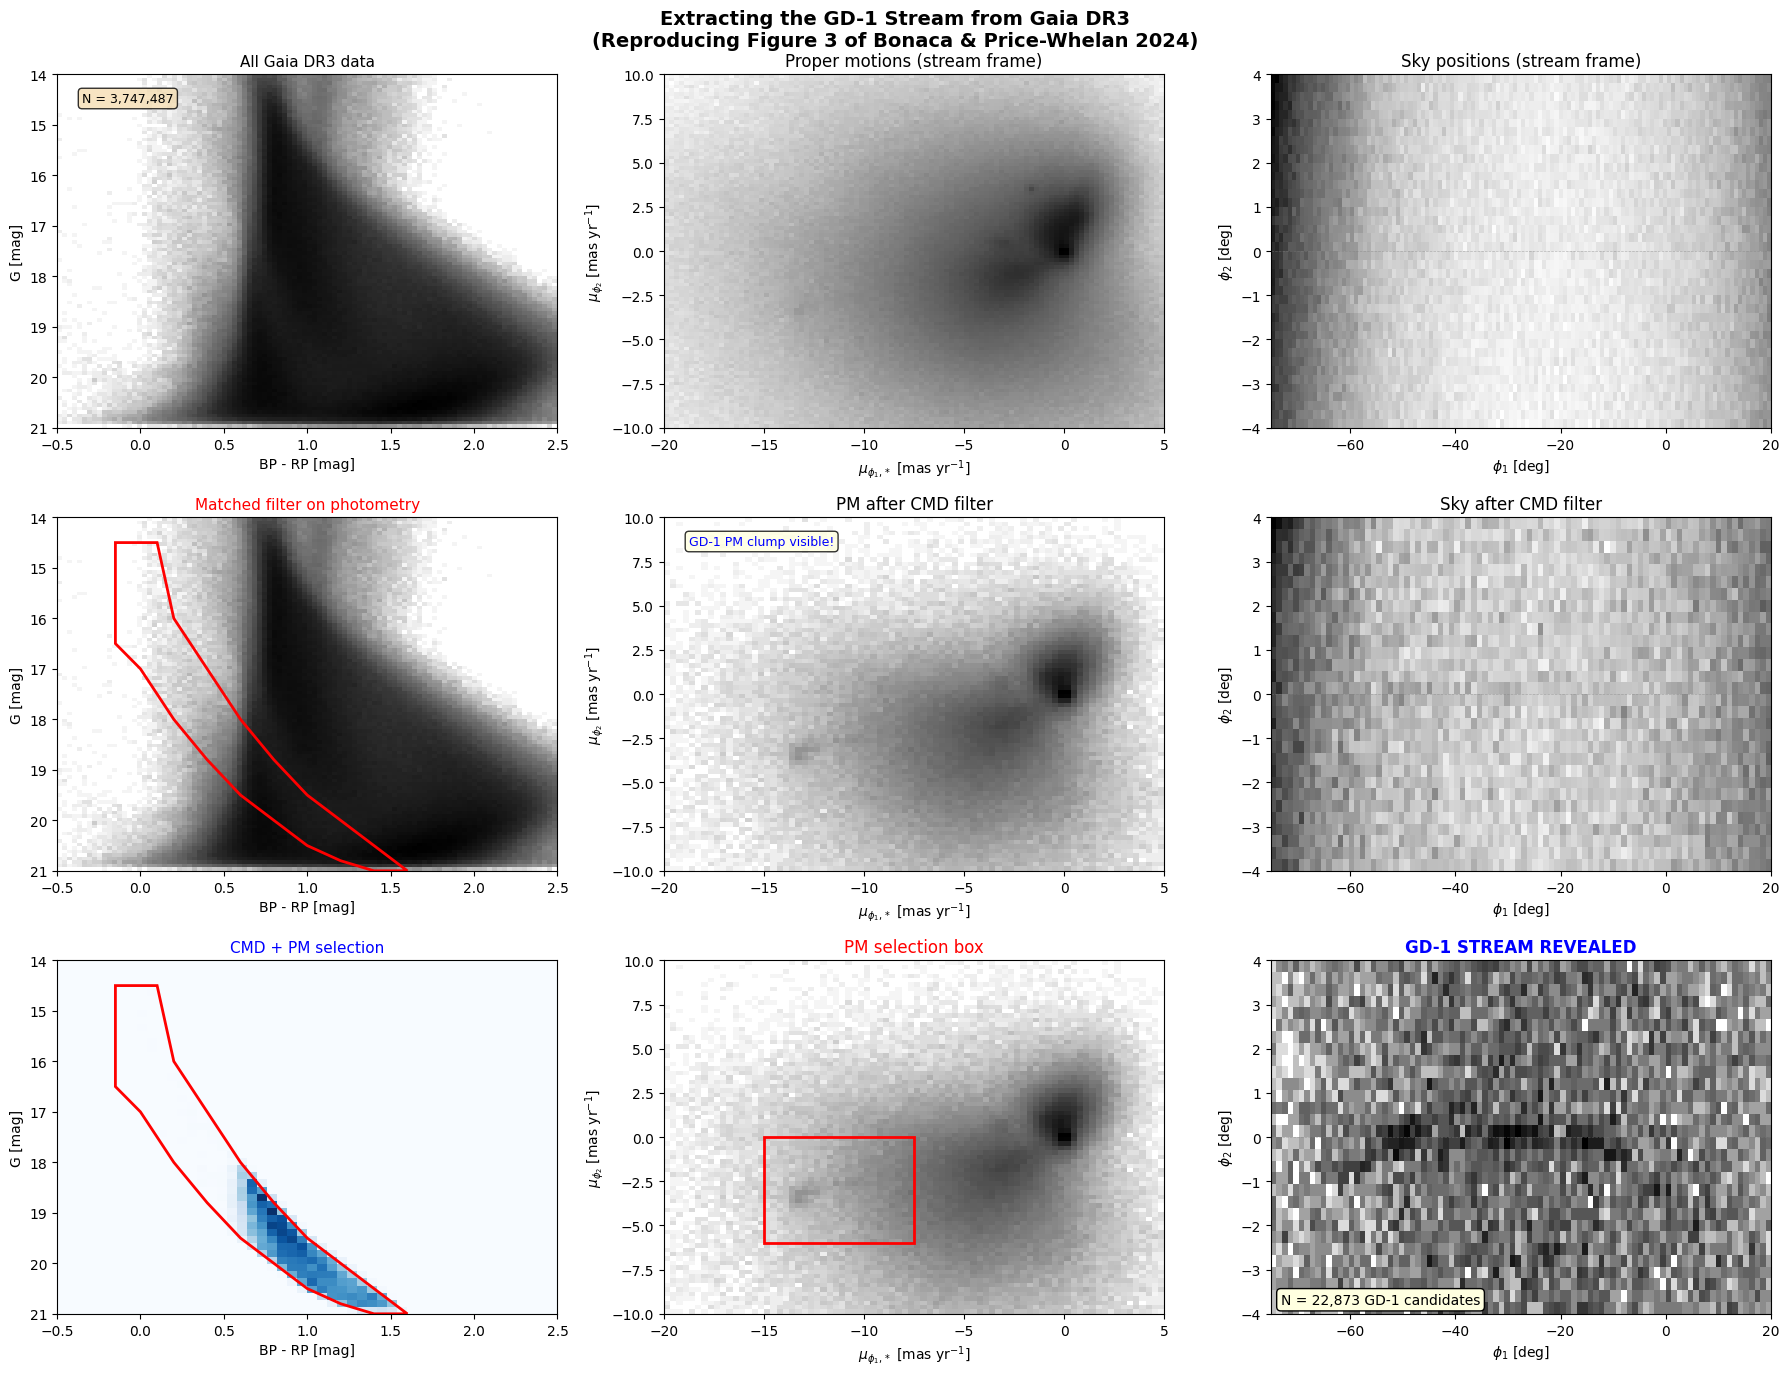


Saved: gd1_stream_extraction.png


In [28]:
"""
    Create the three-row visualization from Figure 3 of the paper.

    Row 1: All data (CMD, proper motions, sky positions)
    Row 2: After CMD matched filter
    Row 3: After CMD + proper motion selection
"""


fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    "Extracting the GD-1 Stream from Gaia DR3\n"
    "(Reproducing Figure 3 of Bonaca & Price-Whelan 2024)",
    fontsize=14,
    fontweight="bold",
)

# --- Plotting parameters ---
sky_range = [(-75, 20), (-4, 4)]
pm_range = [(-20, 5), (-10, 10)]
cmd_range = [(-0.5, 2.5), (21, 14)]

# Color maps
cmap = "Greys"

# ========= ROW 1: All data =========
row = 0
in_region = np.abs(phi2) < 8

# CMD
ax = axes[row, 0]
ax.hist2d(
    bp_rp[in_region],
    g_mag[in_region],
    bins=[100, 100],
    range=[cmd_range[0], (14, 21)],
    cmap=cmap,
    norm=mcolors.LogNorm(),
)
ax.set_xlabel("BP - RP [mag]")
ax.set_ylabel("G [mag]")
ax.set_ylim(21, 14)
ax.set_title("All Gaia DR3 data", fontsize=11)
ax.text(
    0.05,
    0.95,
    f"N = {in_region.sum():,}",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Proper motions
ax = axes[row, 1]
ax.hist2d(
    pm_phi1[in_region],
    pm_phi2[in_region],
    bins=[100, 100],
    range=[pm_range[0], pm_range[1]],
    cmap=cmap,
    norm=mcolors.LogNorm(),
)
ax.set_xlabel(r"$\mu_{\phi_1,*}$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_{\phi_2}$ [mas yr$^{-1}$]")
ax.set_title("Proper motions (stream frame)")

# Sky positions
ax = axes[row, 2]
ax.hist2d(
    phi1[in_region],
    phi2[in_region],
    bins=[120, 40],
    range=[sky_range[0], sky_range[1]],
    cmap=cmap,
    norm=mcolors.LogNorm(),
)
ax.set_xlabel(r"$\phi_1$ [deg]")
ax.set_ylabel(r"$\phi_2$ [deg]")
ax.set_title("Sky positions (stream frame)")
ax.axhline(0, color="gray", ls="--", alpha=0.5, lw=0.5)

# ========= ROW 2: After CMD matched filter =========
row = 1
mask2 = cmd_mask & in_region

# CMD with polygon
ax = axes[row, 0]
ax.hist2d(
    bp_rp[in_region],
    g_mag[in_region],
    bins=[100, 100],
    range=[cmd_range[0], (14, 21)],
    cmap=cmap,
    norm=mcolors.LogNorm(),
)
# Draw selection polygon
poly = plt.Polygon(cmd_polygon, fill=False, edgecolor="red", linewidth=2, linestyle="-")
ax.add_patch(poly)
ax.set_xlabel("BP - RP [mag]")
ax.set_ylabel("G [mag]")
ax.set_ylim(21, 14)
ax.set_title("Matched filter on photometry", fontsize=11, color="red")

# PM after CMD filter
ax = axes[row, 1]
if mask2.sum() > 0:
    ax.hist2d(
        pm_phi1[mask2],
        pm_phi2[mask2],
        bins=[80, 80],
        range=[pm_range[0], pm_range[1]],
        cmap=cmap,
        norm=mcolors.LogNorm(),
    )
ax.set_xlabel(r"$\mu_{\phi_1,*}$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_{\phi_2}$ [mas yr$^{-1}$]")
ax.set_title("PM after CMD filter")
ax.text(
    0.05,
    0.95,
    "GD-1 PM clump visible!",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    color="blue",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
)

# Sky after CMD filter
ax = axes[row, 2]
if mask2.sum() > 0:
    ax.hist2d(
        phi1[mask2],
        phi2[mask2],
        bins=[90, 30],
        range=[sky_range[0], sky_range[1]],
        cmap=cmap,
        norm=mcolors.LogNorm(),
    )
ax.set_xlabel(r"$\phi_1$ [deg]")
ax.set_ylabel(r"$\phi_2$ [deg]")
ax.set_title("Sky after CMD filter")
ax.axhline(0, color="gray", ls="--", alpha=0.5, lw=0.5)

# ========= ROW 3: After CMD + PM selection =========
row = 2
mask3 = full_mask & in_region

# CMD after full selection
ax = axes[row, 0]
if mask3.sum() > 0:
    ax.hist2d(
        bp_rp[mask3],
        g_mag[mask3],
        bins=[50, 50],
        range=[cmd_range[0], (14, 21)],
        cmap="Blues",
    )
poly = plt.Polygon(cmd_polygon, fill=False, edgecolor="red", linewidth=2, linestyle="-")
ax.add_patch(poly)
ax.set_xlabel("BP - RP [mag]")
ax.set_ylabel("G [mag]")
ax.set_ylim(21, 14)
ax.set_title("CMD + PM selection", fontsize=11, color="blue")

# PM with selection box
ax = axes[row, 1]
if mask2.sum() > 0:
    ax.hist2d(
        pm_phi1[mask2],
        pm_phi2[mask2],
        bins=[80, 80],
        range=[pm_range[0], pm_range[1]],
        cmap=cmap,
        norm=mcolors.LogNorm(),
    )
# Draw PM selection box
rect = plt.Rectangle(
    (pm_phi1_range[0], pm_phi2_range[0]),
    pm_phi1_range[1] - pm_phi1_range[0],
    pm_phi2_range[1] - pm_phi2_range[0],
    fill=False,
    edgecolor="red",
    linewidth=2,
)
ax.add_patch(rect)
ax.set_xlabel(r"$\mu_{\phi_1,*}$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_{\phi_2}$ [mas yr$^{-1}$]")
ax.set_title("PM selection box", color="red")

# FINAL: Sky positions — THE STREAM
ax = axes[row, 2]
# if mask3.sum() > 0:
#     ax.scatter(phi1[mask3], phi2[mask3], s=1, c="black", alpha=0.5, rasterized=True)
ax.hist2d(
    phi1[mask3],
    phi2[mask3],
    bins=[90, 30],
    range=[sky_range[0], sky_range[1]],
    cmap=cmap,
    norm=mcolors.LogNorm(),
)
ax.set_xlabel(r"$\phi_1$ [deg]")
ax.set_ylabel(r"$\phi_2$ [deg]")
ax.set_xlim(sky_range[0])
ax.set_ylim(sky_range[1])
ax.set_title("GD-1 STREAM REVEALED", fontsize=12, fontweight="bold", color="blue")
ax.axhline(0, color="gray", ls="--", alpha=0.5, lw=0.5)


ax.text(
    0.02,
    0.02,
    f"N = {mask3.sum():,} GD-1 candidates",
    transform=ax.transAxes,
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="lightyellow"),
)

plt.tight_layout()
plt.savefig("gd1_stream_extraction.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nSaved: gd1_stream_extraction.png")

In [12]:
import numpy as np

R_fwd = np.array(
    [
        [-0.4776303088, -0.1738432154, 0.8611897727],
        [0.510844589, -0.8524449229, 0.111245042],
        [0.7147776536, 0.4930681392, 0.4959603976],
    ]
)
R_inv = R_fwd.T

# Sample the FULL interior of the stream-frame rectangle
phi1_grid, phi2_grid = np.meshgrid(
    np.linspace(-100, 20, 500),
    np.linspace(-8, 5, 500),
)
p1 = np.deg2rad(phi1_grid.ravel())
p2 = np.deg2rad(phi2_grid.ravel())

xyz_stream = np.vstack([np.cos(p2) * np.cos(p1), np.cos(p2) * np.sin(p1), np.sin(p2)])
xyz_icrs = R_inv @ xyz_stream

ra = np.rad2deg(np.arctan2(xyz_icrs[1], xyz_icrs[0])) % 360
dec = np.rad2deg(np.arcsin(np.clip(xyz_icrs[2], -1, 1)))

print(f"Required RA:  {ra.min():.1f}° to {ra.max():.1f}°")
print(f"Required Dec: {dec.min():.1f}° to {dec.max():.1f}°")

Required RA:  111.4° to 242.8°
Required Dec: -19.0° to 65.3°


In [ ]:
from streams import Streams

(
    Streams.GD1.ra_range,
    Streams.GD1.dec_range,
    Streams.GD1.phi1_range,
    Streams.GD1.phi2_range,
)

((110.0, 244.0), (-21.0, 67.0), (-100, 20), (-8, 5))